In [27]:
import numpy as np

In [28]:
class MultinomialRegression:
      def __init__(self, lr=0.1, iterations=500):
        self.lr = lr
        self.iterations = iterations
        self.W = None
        self.b = None

      def softmax(self,z):
        z = z - np.max(z, axis=1, keepdims=True) # improve numerical stability and prevent overflow in exp()
        exp_z= np.exp(z)
        return  exp_z/np.sum(exp_z, axis=1, keepdims=True)
      
      def one_hot(self, y, num_classes):
        
        y = np.array(y, dtype=int)
        identity = np.eye(num_classes)
    
        # Use y to PICK rows from the identity matrix
        one_hot = identity[y]
        return one_hot
        
      def compute_loss(Self,y_true,y_hat):
         epsilon = 1e-15  # small value to avoid log(0)
         y_hat = np.clip(y_hat, epsilon, 1 - epsilon)

        # Since y_true is one-hot, this picks only the correct class probability
         loss_per_sample = np.sum(y_true * np.log(y_hat), axis=1)
         loss = - np.mean(loss_per_sample)

         return loss
      
      def compute_gradients(self, X, y_true, y_hat):
  
        n_samples = X.shape[0]
        dz = y_hat - y_true  

        
        dW = (X.T @ dz) / n_samples  
        db = np.sum(dz, axis=0) / n_samples   

        return dW, db
      
      def fit(self, X, y):
   
        # Get dimensions from data
        n_samples, n_features = X.shape
        n_classes = 10

        # Initialize weights and bias (now we know shapes)
        self.W = np.zeros((n_features, n_classes))
        self.b = np.zeros(n_classes)

        # Convert labels to one-hot encoding
        y_one_hot = self.one_hot(y, n_classes)

        # Training loop
        for i in range(self.iterations):

            z = X @ self.W + self.b             
            y_hat = self.softmax(z)             

            #  Compute loss 
            if i % 100 == 0:
                loss = self.compute_loss(y_one_hot, y_hat)
                print(f"Iteration {i}, Loss: {loss:.4f}")

            #  Compute gradients
            dW, db = self.compute_gradients(X, y_one_hot, y_hat)

            #  Update parameters
            self.W -= self.lr * dW
            self.b -= self.lr * db

      def predict(self, X):
        if self.W is None:
            raise ValueError("Model is not trained yet. Call fit() first.")

        # Compute scores
        z = X @ self.W + self.b

        y_hat = self.softmax(z)

        # Pick class with highest probability
        y_pred = np.argmax(y_hat, axis=1)

        return y_pred





In [29]:
from preprocessing2 import preprocess
X_train, y_train, X_val, y_val, X_test, y_test, _ = preprocess( feature_method="hog" , n_pca=100)

model = MultinomialRegression(lr=0.5, iterations=1200)
model.fit(X_train, y_train)

Iteration 0, Loss: 2.3026
Iteration 100, Loss: 0.6038
Iteration 200, Loss: 0.4391
Iteration 300, Loss: 0.3729
Iteration 400, Loss: 0.3350
Iteration 500, Loss: 0.3096
Iteration 600, Loss: 0.2911
Iteration 700, Loss: 0.2768
Iteration 800, Loss: 0.2652
Iteration 900, Loss: 0.2556
Iteration 1000, Loss: 0.2475
Iteration 1100, Loss: 0.2404


In [30]:
def evaluate_model(X, y, model, dataset_name="Validation"):
    """
    Evaluate multiclass model (digits 0-9)
    """

    y_pred = model.predict(X)
    y_true = y

    n_classes = 10  # MNIST

    #  Confusion Matrix
    cm = np.zeros((n_classes, n_classes), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[int(t), int(p)] += 1

    #  Accuracy
    accuracy = np.trace(cm) / np.sum(cm)

    #  Precision, Recall, F1 per class
    precision = np.zeros(n_classes)
    recall = np.zeros(n_classes)
    f1 = np.zeros(n_classes)

    for i in range(n_classes):
        tp = cm[i, i]
        fp = np.sum(cm[:, i]) - tp
        fn = np.sum(cm[i, :]) - tp

        precision[i] = tp / (tp + fp + 1e-9)
        recall[i]    = tp / (tp + fn + 1e-9)
        f1[i]        = 2 * precision[i] * recall[i] / (precision[i] + recall[i] + 1e-9)

    #  Macro F1
    macro_f1 = np.mean(f1)

    #  Print results
    print(f"\n--- {dataset_name} Results ---")
    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Macro F1  : {macro_f1:.4f}")

    # Confusion Matrix
    print("\nConfusion Matrix:")
    print(cm)

    # Classification Report
    print("\nClassification Report:")
    print(f"{'Class':<10}{'Precision':>10}{'Recall':>10}{'F1-score':>12}")

    for i in range(n_classes):
        print(f"{i:<10}{precision[i]:>10.2f}{recall[i]:>10.2f}{f1[i]:>12.2f}")

In [31]:
evaluate_model(X_val, y_val, model, "Validation")


--- Validation Results ---
Accuracy  : 0.9537
Macro F1  : 0.9535

Confusion Matrix:
[[565   6   8   1   0   3   1   0   1   2]
 [  0 616   4   1   3   0   1   1   4   0]
 [  3   0 576   4   6   1   2   5   3   0]
 [  0   0  13 601   1   6   0   1   3   2]
 [  0   5   0   1 568   0   2   4   0  15]
 [  1   2   1  17   0 509   2   0  13   4]
 [  0   0   1   0   4   2 563   0   0   1]
 [  1   0   6   1   5   0   1 632   1  21]
 [  4   4   7   4   1   4   4   1 563   5]
 [  5   3   0   8   9   3   0  15   4 529]]

Classification Report:
Class      Precision    Recall    F1-score
0               0.98      0.96        0.97
1               0.97      0.98        0.97
2               0.94      0.96        0.95
3               0.94      0.96        0.95
4               0.95      0.95        0.95
5               0.96      0.93        0.95
6               0.98      0.99        0.98
7               0.96      0.95        0.95
8               0.95      0.94        0.95
9               0.91      0.92

In [32]:

evaluate_model(X_test, y_test, model, "Test")


--- Test Results ---
Accuracy  : 0.9436
Macro F1  : 0.9434

Confusion Matrix:
[[ 954    3    7    0    3    4    2    0    2    5]
 [   2 1119    4    3    4    1    1    0    1    0]
 [   7    2  962   12    6    2    4   16   19    2]
 [   2    0   17  953    2   16    0   11    6    3]
 [   0    8    1    0  929    0    4    6    6   28]
 [   4    1    0   19    0  840    5    1   17    5]
 [   7    6    1    0   10    7  922    0    5    0]
 [   0    8   37    1   12    0    0  923    9   38]
 [  10    4   13    5    3    5    4    6  914   10]
 [   4    4    3   11   30    8    1   23    5  920]]

Classification Report:
Class      Precision    Recall    F1-score
0               0.96      0.97        0.97
1               0.97      0.99        0.98
2               0.92      0.93        0.93
3               0.95      0.94        0.95
4               0.93      0.95        0.94
5               0.95      0.94        0.95
6               0.98      0.96        0.97
7               0.94  

### # Learning Curve Analysis

Learning curves help evaluate how the `MultinomialRegression` model performs as the training dataset size increases.

By comparing training and validation accuracy, they provide insight into the model’s learning behavior and generalization capability.

These curves are useful for detecting:
- Underfitting
- Overfitting
- Good generalization

GENERATING LEARNING CURVES

Training on 5400 samples (10%)
Iteration 0, Loss: 2.3026
Iteration 100, Loss: 0.5929
Iteration 200, Loss: 0.4285
Iteration 300, Loss: 0.3622
Iteration 400, Loss: 0.3240
Iteration 500, Loss: 0.2983
Iteration 600, Loss: 0.2793
Iteration 700, Loss: 0.2645
Iteration 800, Loss: 0.2525
Iteration 900, Loss: 0.2424
Train Accuracy     : 0.9383
Validation Accuracy: 0.9477

Training on 10800 samples (20%)
Iteration 0, Loss: 2.3026
Iteration 100, Loss: 0.6085
Iteration 200, Loss: 0.4425
Iteration 300, Loss: 0.3755
Iteration 400, Loss: 0.3370
Iteration 500, Loss: 0.3112
Iteration 600, Loss: 0.2922
Iteration 700, Loss: 0.2774
Iteration 800, Loss: 0.2654
Iteration 900, Loss: 0.2554
Train Accuracy     : 0.9326
Validation Accuracy: 0.9522

Training on 16200 samples (30%)
Iteration 0, Loss: 2.3026
Iteration 100, Loss: 0.6033
Iteration 200, Loss: 0.4389
Iteration 300, Loss: 0.3729
Iteration 400, Loss: 0.3351
Iteration 500, Loss: 0.3098
Iteration 600, Loss: 0.2913
Iteration 700

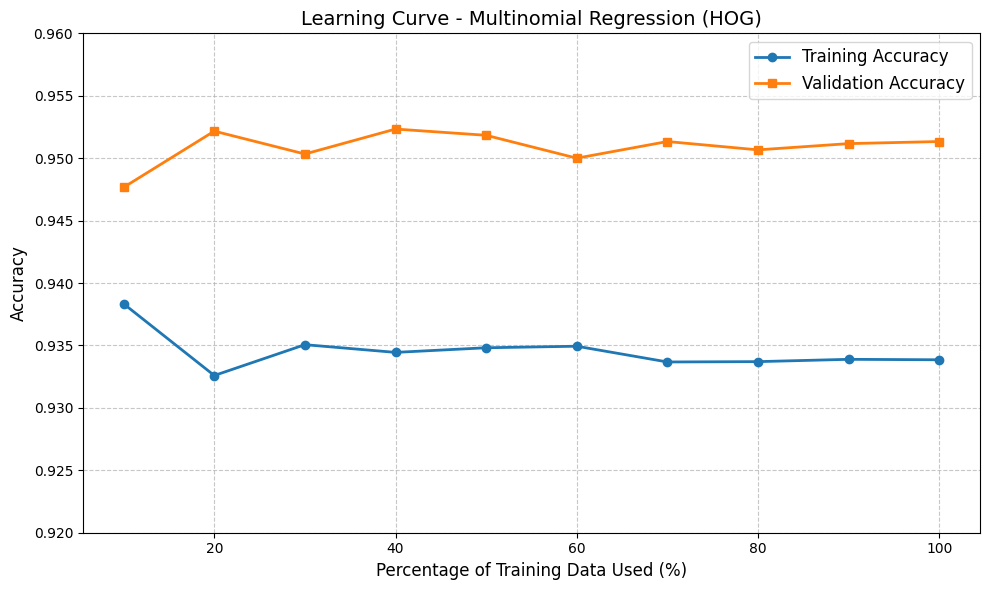


MODEL DIAGNOSIS
Final Training Accuracy  : 0.9339
Final Validation Accuracy: 0.9513
Gap                      : 0.0175

Diagnosis: GOOD GENERALIZATION
The model generalizes well.


In [33]:
import numpy as np
import matplotlib.pyplot as plt

from preprocessing2 import (
    preprocess,
    custom_accuracy_score
)

# Model and preprocessing settings

FEATURE_METHOD = "hog"
N_PCA = 100

LEARNING_RATE = 0.5
ITERATIONS = 1000

# Load dataset

if FEATURE_METHOD == "pca":

    X_train, y_train, X_val, y_val, X_test, y_test, _ = preprocess(
        feature_method="pca",
        n_pca=N_PCA
    )

else:

    X_train, y_train, X_val, y_val, X_test, y_test, _ = preprocess(
        feature_method=FEATURE_METHOD
    )

# Learning curve settings

train_fractions = np.linspace(0.1, 1.0, 10)

train_scores = []
val_scores = []

total_train_samples = len(X_train)

print("=" * 60)
print("GENERATING LEARNING CURVES")
print("=" * 60)

# Train model on different dataset sizes

for fraction in train_fractions:

    subset_size = int(total_train_samples * fraction)

    print(
        f"\nTraining on {subset_size} samples "
        f"({int(fraction * 100)}%)"
    )

    # Random subset selection

    indices = np.random.choice(
        total_train_samples,
        subset_size,
        replace=False
    )

    X_subset = X_train[indices]
    y_subset = y_train[indices]

    # Create model

    curve_model = MultinomialRegression(
        lr=LEARNING_RATE,
        iterations=ITERATIONS
    )

    # Train model

    curve_model.fit(X_subset, y_subset)

    # Generate predictions

    train_preds = curve_model.predict(X_subset)
    val_preds = curve_model.predict(X_val)

    # Compute accuracy

    train_acc = custom_accuracy_score(
        y_subset,
        train_preds
    )

    val_acc = custom_accuracy_score(
        y_val,
        val_preds
    )

    train_scores.append(train_acc)
    val_scores.append(val_acc)

    print(f"Train Accuracy     : {train_acc:.4f}")
    print(f"Validation Accuracy: {val_acc:.4f}")

# Plot learning curves

plt.figure(figsize=(10, 6))

plt.plot(
    train_fractions * 100,
    train_scores,
    marker="o",
    linewidth=2,
    label="Training Accuracy"
)

plt.plot(
    train_fractions * 100,
    val_scores,
    marker="s",
    linewidth=2,
    label="Validation Accuracy"
)

plt.title(
    f"Learning Curve - Multinomial Regression ({FEATURE_METHOD.upper()})",
    fontsize=14
)

plt.xlabel(
    "Percentage of Training Data Used (%)",
    fontsize=12
)

plt.ylabel(
    "Accuracy",
    fontsize=12
)

plt.legend(fontsize=12)

plt.grid(
    True,
    linestyle="--",
    alpha=0.7
)

plt.ylim(0.92, 0.96)

plt.tight_layout()
plt.show()

# Final model diagnosis

final_train = train_scores[-1]
final_val = val_scores[-1]

gap = np.abs(final_train - final_val)

print("\n" + "=" * 60)
print("MODEL DIAGNOSIS")
print("=" * 60)

print(f"Final Training Accuracy  : {final_train:.4f}")
print(f"Final Validation Accuracy: {final_val:.4f}")
print(f"Gap                      : {gap:.4f}")

if final_train < 0.85 and final_val < 0.85:

    print("\nDiagnosis: UNDERFITTING")
    print("Suggestions:")
    print("- Increase iterations")
    print("- Use better features (HOG/CNN)")
    print("- Increase PCA dimensions")

elif gap > 0.05:

    print("\nDiagnosis: OVERFITTING")
    print("Suggestions:")
    print("- Add regularization")
    print("- Reduce dimensionality")
    print("- Use more training data")

else:

    print("\nDiagnosis: GOOD GENERALIZATION")
    print("The model generalizes well.")

## Cross validation


In [34]:
import numpy as np

from preprocessing2 import (
    preprocess,
    custom_macro_f1_score,
    k_fold_indices
)


# Feature extraction methods to test
feature_methods = [
    "pca",
    "hog"
]


# Hyperparameter grid
param_grid = {
    "lr": [0.01, 0.08, 0.5],
    "iterations": [300, 600, 1000]
}

# PCA dimensions to test
pca_components_list = [100]


# Tracking best results
best_f1_score = 0
best_params = {}


# Start experiments
experiment_num = 1

for feature_method in feature_methods:

    print("\n" + "=" * 70)
    print(f"TESTING FEATURE METHOD: {feature_method.upper()}")
    print("=" * 70)

    
    # PCA requires trying different n_pca values
    if feature_method == "pca":

        pca_values = pca_components_list

    else:
        # flatten and hog do not need PCA values
        pca_values = [None]

    
    # Loop over PCA dimensions if needed
    for n_pca in pca_values:

       
        if feature_method == "pca":

            print(f"\nUsing PCA with n_components = {n_pca}")

            X_train, y_train, X_val, y_val, X_test, y_test, _ = preprocess(
                feature_method="pca",
                n_pca=n_pca
            )

        else:

            print(f"\nUsing feature method = {feature_method}")

            X_train, y_train, X_val, y_val, X_test, y_test, _ = preprocess(
                feature_method=feature_method
            )

       
        # Create folds
        folds = k_fold_indices(X_train, k=3)

     
        # Hyperparameter Search
        for lr in param_grid["lr"]:

            for iterations in param_grid["iterations"]:

                print(
                    f"\nExperiment {experiment_num}"
                    f" | Method: {feature_method}"
                    f" | PCA: {n_pca}"
                    f" | LR: {lr}"
                    f" | Iterations: {iterations}"
                )

                fold_f1_scores = []

                
                # Cross Validation
                for fold_num, (train_idx, val_idx) in enumerate(folds):

                    # Split fold data
                    X_fold_train = X_train[train_idx]
                    y_fold_train = y_train[train_idx]

                    X_fold_val = X_train[val_idx]
                    y_fold_val = y_train[val_idx]

                    # Create model
                    cv_model = MultinomialRegression(
                        lr=lr,
                        iterations=iterations
                    )

                    # Train model
                    cv_model.fit(X_fold_train, y_fold_train)

                    # Predict
                    preds = cv_model.predict(X_fold_val)

                    # Compute Macro F1
                    fold_f1 = custom_macro_f1_score(
                        y_fold_val,
                        preds,
                        n_classes=10
                    )

                    fold_f1_scores.append(fold_f1)

                    print(
                        f"    Fold {fold_num + 1} "
                        f"Macro F1: {fold_f1:.4f}"
                    )

               
                # Average F1 across folds
                avg_f1 = np.mean(fold_f1_scores)

                print(
                    f"--> Average 3-Fold Macro F1: "
                    f"{avg_f1:.4f}"
                )

                
                # Save best configuration
                if avg_f1 > best_f1_score:

                    best_f1_score = avg_f1

                    best_params = {
                        "feature_method": feature_method,
                        "n_pca": n_pca,
                        "lr": lr,
                        "iterations": iterations
                    }

                experiment_num += 1


# Final Results
print("\n" + "=" * 70)
print("GRID SEARCH COMPLETE")
print("=" * 70)

print(f"\nBest Macro F1 Score: {best_f1_score:.4f}")

print("\nBest Configuration:")
for key, value in best_params.items():
    print(f"{key}: {value}")


TESTING FEATURE METHOD: PCA

Using PCA with n_components = 100

Experiment 1 | Method: pca | PCA: 100 | LR: 0.01 | Iterations: 300
Iteration 0, Loss: 2.3026
Iteration 100, Loss: 1.5319
Iteration 200, Loss: 1.1832
    Fold 1 Macro F1: 0.7832
Iteration 0, Loss: 2.3026
Iteration 100, Loss: 1.5337
Iteration 200, Loss: 1.1859
    Fold 2 Macro F1: 0.7848
Iteration 0, Loss: 2.3026
Iteration 100, Loss: 1.5396
Iteration 200, Loss: 1.1913
    Fold 3 Macro F1: 0.7936
--> Average 3-Fold Macro F1: 0.7872

Experiment 2 | Method: pca | PCA: 100 | LR: 0.01 | Iterations: 600
Iteration 0, Loss: 2.3026
Iteration 100, Loss: 1.5319
Iteration 200, Loss: 1.1832
Iteration 300, Loss: 0.9989
Iteration 400, Loss: 0.8852
Iteration 500, Loss: 0.8078
    Fold 1 Macro F1: 0.8231
Iteration 0, Loss: 2.3026
Iteration 100, Loss: 1.5337
Iteration 200, Loss: 1.1859
Iteration 300, Loss: 1.0019
Iteration 400, Loss: 0.8883
Iteration 500, Loss: 0.8109
    Fold 2 Macro F1: 0.8215
Iteration 0, Loss: 2.3026
Iteration 100, Loss:

### Testing best parameters given by cross validation

In [35]:
from preprocessing2 import preprocess
X_train, y_train, X_val, y_val, X_test, y_test, _ = preprocess( feature_method="hog" , n_pca=100)
model1 = MultinomialRegression(lr=0.5, iterations=1000)
model1.fit(X_train, y_train)

Iteration 0, Loss: 2.3026
Iteration 100, Loss: 0.6038
Iteration 200, Loss: 0.4391
Iteration 300, Loss: 0.3729
Iteration 400, Loss: 0.3350
Iteration 500, Loss: 0.3096
Iteration 600, Loss: 0.2911
Iteration 700, Loss: 0.2768
Iteration 800, Loss: 0.2652
Iteration 900, Loss: 0.2556


In [36]:
evaluate_model(X_test, y_test, model1, "Test")


--- Test Results ---
Accuracy  : 0.9405
Macro F1  : 0.9403

Confusion Matrix:
[[ 953    3    7    0    3    4    2    0    2    6]
 [   2 1118    5    4    3    1    1    0    1    0]
 [   8    2  957   13    7    2    4   16   20    3]
 [   3    0   17  952    2   16    0   12    5    3]
 [   0   10    1    0  922    0    4    7    7   31]
 [   4    1    0   20    0  837    5    1   18    6]
 [   7    6    1    0   10    7  921    0    6    0]
 [   0    8   40    1   12    0    0  917    9   41]
 [  10    4   12    5    4    6    5    6  912   10]
 [   4    4    3   11   32    8    1   25    5  916]]

Classification Report:
Class      Precision    Recall    F1-score
0               0.96      0.97        0.97
1               0.97      0.99        0.98
2               0.92      0.93        0.92
3               0.95      0.94        0.94
4               0.93      0.94        0.93
5               0.95      0.94        0.94
6               0.98      0.96        0.97
7               0.93  

### Trying preprocessing with CNN features

In [37]:
from preprocessing2 import preprocess
X_train_cnn, y_train_cnn, X_val_cnn, y_val_cnn, X_test_cnn, y_test_cnn, _ = preprocess( feature_method="cnn" )

CNN Features Loaded: Train=54000, Val=6000, Test=10000


In [38]:
model2=MultinomialRegression(iterations=1000,lr=0.0003)
model2.fit(X_train_cnn,y_train_cnn)

Iteration 0, Loss: 2.3026
Iteration 100, Loss: 0.8460
Iteration 200, Loss: 0.6963
Iteration 300, Loss: 0.6227
Iteration 400, Loss: 0.5763
Iteration 500, Loss: 0.5435
Iteration 600, Loss: 0.5185
Iteration 700, Loss: 0.4986
Iteration 800, Loss: 0.4823
Iteration 900, Loss: 0.4685


In [39]:
evaluate_model(X_test_cnn,y_test_cnn,model2,"Test")


--- Test Results ---
Accuracy  : 0.8776
Macro F1  : 0.8759

Confusion Matrix:
[[ 936    0    5    1    2    9   15    0    1   11]
 [   0 1108    0    0    7    3    1   15    0    1]
 [   4    2  798   24   29   47   20   28   49   31]
 [   1    0   32  867    3   60    3    2   34    8]
 [   0   21   35    2  882    4   12    7   13    6]
 [   4    2   23  105    5  708   18    9   13    5]
 [   5    5    7    3   21   28  882    2    3    2]
 [   0   25   34    4   57    6    1  868    6   27]
 [   4    0   29   29    4    8    6    1  867   26]
 [  21    5   25   11   20   12    4   15   36  860]]

Classification Report:
Class      Precision    Recall    F1-score
0               0.96      0.96        0.96
1               0.95      0.98        0.96
2               0.81      0.77        0.79
3               0.83      0.86        0.84
4               0.86      0.90        0.88
5               0.80      0.79        0.80
6               0.92      0.92        0.92
7               0.92  